In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load cleaned dataset
df = pd.read_csv("W:\Anil\Infotact Solutions\Project2 Files\Cloning\SaaS-E-Commerce-Cohort-Retention-CLTV-Analysis\Data\Cleaned\Cleaned_Ecommerce.csv")

In [3]:
# Convert dates
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["First_transaction_date"] = pd.to_datetime(df["First_transaction_date"])

In [ ]:
# Calculate customer-level CLTV table
customer_cltv = (
    df.groupby("customer_id")
      .agg(
          acquisition_channel=("acquisition_channel", "first"),
          country=("country", "first"),
          first_purchase=("transaction_date", "min"),
          last_purchase=("transaction_date", "max"),
          orders=("order_id", "nunique"),
          total_revenue=("revenue", "sum")
      )
      .reset_index()
)

In [ ]:
#Calculate Customer Lifetime
customer_cltv["lifetime_months"] = (
    (customer_cltv["last_purchase"].dt.year -
     customer_cltv["first_purchase"].dt.year) * 12
    +
    (customer_cltv["last_purchase"].dt.month -
     customer_cltv["first_purchase"].dt.month)
    + 1
)

customer_cltv[[
    "customer_id",
    "first_purchase",
    "last_purchase",
    "lifetime_months"
]].head()

,customer_id,first_purchase,last_purchase,lifetime_months
0,CUST000001,2023-05-24,2023-05-24,1
1,CUST000002,2024-03-18,2024-10-12,8
2,CUST000003,2023-10-21,2023-10-21,1
3,CUST000004,2023-04-25,2023-12-04,9
4,CUST000005,2023-04-13,2023-06-02,3


In [ ]:
#Calculate AOV & Calculate Purchase Frequency
customer_cltv["AOV"] = (
    customer_cltv["total_revenue"] /
    customer_cltv["orders"]
)

customer_cltv["purchase_frequency"] = (
    customer_cltv["orders"] /
    customer_cltv["lifetime_months"]
)

customer_cltv.head()

,customer_id,acquisition_channel,country,first_purchase,last_purchase,orders,total_revenue,lifetime_months,AOV,purchase_frequency
0,CUST000001,Instagram,Canada,2023-05-24,2023-05-24,1,579.92,1,579.92,1.000000
1,CUST000002,Email,USA,2024-03-18,2024-10-12,7,1472.17,8,210.31,0.875000
2,CUST000003,Facebook Ads,France,2023-10-21,2023-10-21,1,359.76,1,359.76,1.000000
3,CUST000004,Facebook Ads,Germany,2023-04-25,2023-12-04,8,1633.92,9,204.24,0.888889
4,CUST000005,Instagram,UK,2023-04-13,2023-06-02,2,209.94,3,104.97,0.666667


In [ ]:
#Calculate CLTV by segment
def calculate_segment_cltv(group):

    customers = group["customer_id"].nunique()
    orders = group["orders"].sum()
    revenue = group["total_revenue"].sum()

    aov = revenue / orders
    purchase_frequency = orders / customers
    avg_lifetime = group["lifetime_months"].mean()

    historical_cltv = (
        aov *
        purchase_frequency *
        avg_lifetime
    )

    return pd.Series({
        "Customers": customers,
        "Orders": orders,
        "Revenue": revenue,
        "AOV": aov,
        "Purchase_Frequency": purchase_frequency,
        "Avg_Lifetime_Months": avg_lifetime,
        "Historical_CLTV": historical_cltv,
        "Revenue_per_Customer": revenue / customers
    })


channel_cltv = (
    customer_cltv
    .groupby("acquisition_channel")
    .apply(calculate_segment_cltv, include_groups=False)
    .reset_index()
)

channel_cltv

,acquisition_channel,Customers,Orders,Revenue,AOV,Purchase_Frequency,Avg_Lifetime_Months,Historical_CLTV,Revenue_per_Customer
0,Direct,2747.0,10312.0,3350333.47,324.896574,3.753913,3.953768,4822.147948,1219.633589
1,Email,2674.0,9939.0,3241572.78,326.146773,3.716904,3.873598,4695.792282,1212.256088
2,Facebook Ads,2699.0,10115.0,3284639.73,324.729583,3.747684,3.876621,4717.785572,1216.983968
3,Google Ads,2675.0,10191.0,3297271.96,323.547440,3.809720,3.971963,4895.940547,1232.625032
4,Instagram,2781.0,10682.0,3460426.96,323.949350,3.841064,4.028407,5012.588405,1244.310306
5,Organic Search,2703.0,10245.0,3321020.31,324.160108,3.790233,3.946726,4849.114591,1228.642364
6,Referral,2797.0,10288.0,3307095.45,321.451735,3.678227,3.850912,4553.211488,1182.372345


In [16]:
country_cltv = (
    customer_cltv
    .groupby("country")
    .apply(calculate_segment_cltv, include_groups=False)
    .reset_index()
)

country_cltv

,country,Customers,Orders,Revenue,AOV,Purchase_Frequency,Avg_Lifetime_Months,Historical_CLTV,Revenue_per_Customer
0,Australia,3233.0,12369.0,3991463.35,322.698953,3.825858,3.974327,4906.706329,1234.600479
1,Canada,3242.0,11948.0,3923367.40,328.370221,3.685379,3.849476,4658.515485,1210.168846
2,France,3119.0,11757.0,3826265.51,325.445735,3.769477,3.932991,4824.837810,1226.760343
3,Germany,3249.0,12214.0,3939101.01,322.507042,3.759311,3.914435,4745.877406,1212.404127
4,UK,3118.0,11632.0,3714941.72,319.372569,3.730597,3.900577,4647.343592,1191.450199
5,USA,3115.0,11852.0,3867221.67,326.292750,3.804815,4.004173,4971.115881,1241.483682


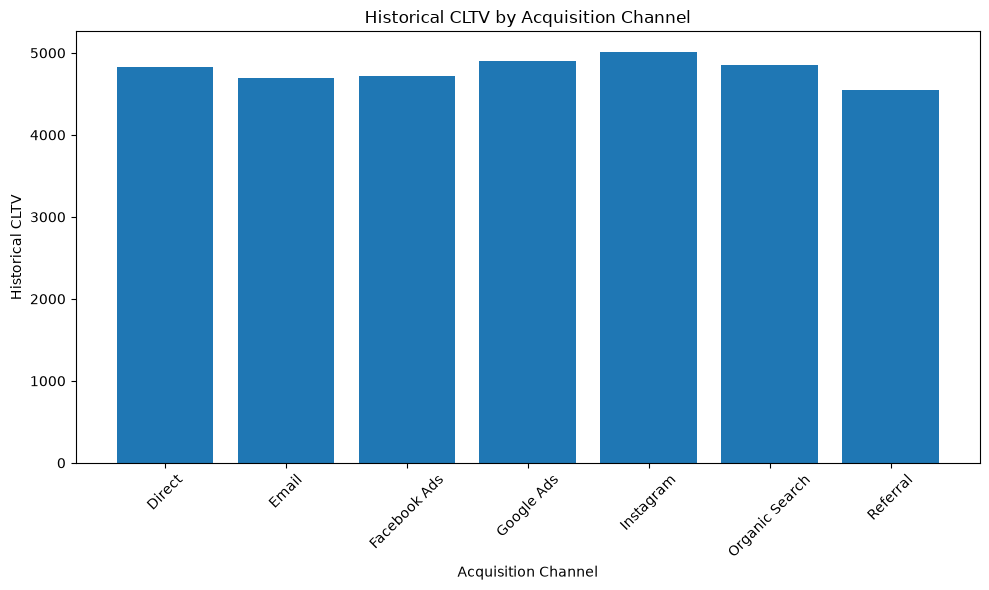

In [13]:
#CLTV by Acquisition Channel
plt.figure(figsize=(10, 6))

plt.bar(
    channel_cltv["acquisition_channel"],
    channel_cltv["Historical_CLTV"]
)

plt.title("Historical CLTV by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Historical CLTV")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

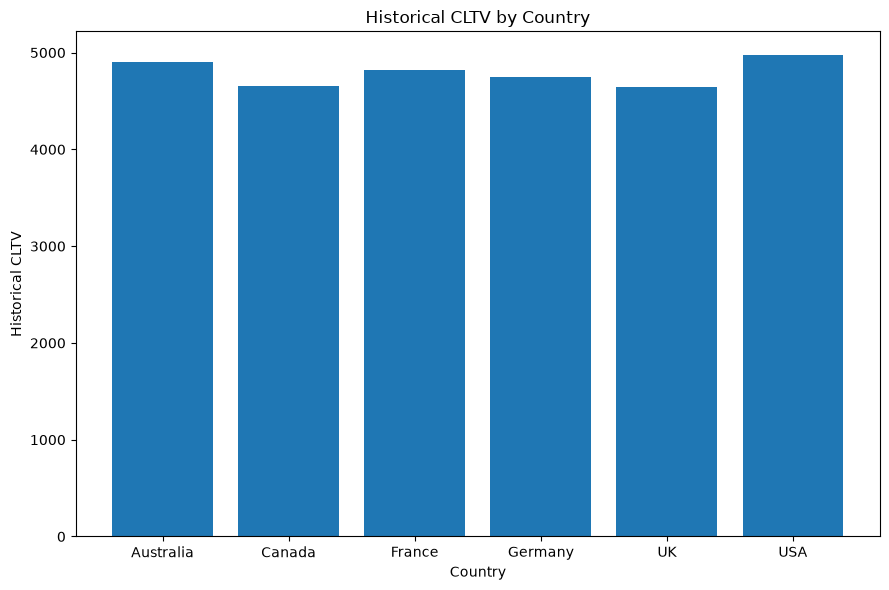

In [17]:
#CLTV by Country

plt.figure(figsize=(9, 6))

plt.bar(
    country_cltv["country"],
    country_cltv["Historical_CLTV"]
)

plt.title("Historical CLTV by Country")
plt.xlabel("Country")
plt.ylabel("Historical CLTV")

plt.tight_layout()
plt.show()